In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("..")

In [3]:
from diffusers import (
    AutoencoderKL,
    DDPMScheduler,
    StableDiffusionInstructPix2PixPipeline,
    UNet2DConditionModel,
)


/home/nero/miniforge3/envs/dawn2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-05 08:09:05.724249: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-05 08:09:05.763846: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-05 08:09:05.763870: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-05 08:09:0

In [4]:
from dawn.models.system2.ldm_support import LatentMotionEstimation

In [5]:
model = LatentMotionEstimation(flow_to_rgb=False, num_inference_steps=2, use_interval=True)

Some weights of the model checkpoint at google/vit-base-patch16-224-in21k were not used when initializing ViTModel: ['pooler.dense.bias', 'pooler.dense.weight']
- This IS expected if you are initializing ViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [6]:
import torch

In [6]:
model.load_state_dict(torch.load("/home/nero/Robotics/DAWN/outputs/DAWN_stage_1/2025-06-21_03-19-43/checkpoints/model_0050000.pth"))

/tmp/ipykernel_3588830/756961149.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home/nero/Robotics/DAWN/outputs/DAWN_stage_1/2025-06-

<All keys matched successfully>

In [66]:
model.pipeline.disable_xformers_memory_efficient_attention()


In [55]:
import json
metadata = json.load(open("/home/nero/Robotics/DAWN/data/calvin/dataset_opt/task_D_D/validation/episodes/659/metadata.json","r"))
metadata['language']

'slide up the switch'

In [9]:
from PIL import Image
import numpy as np
import torch

img_pil = Image.open("/home/nero/Robotics/DAWN/data/calvin/dataset_opt/task_D_D/validation/episodes/659/rgb_static/0002.jpg").convert("RGB")
img = torch.tensor(np.array(img_pil)).unsqueeze(0).permute(0, 3, 1, 2) / 255.

img2_pil = Image.open("/home/nero/Robotics/DAWN/data/calvin/dataset_opt/task_D_D/validation/episodes/659/rgb_static/0012.jpg").convert("RGB")
img2 = torch.tensor(np.array(img2_pil)).unsqueeze(0).permute(0, 3, 1, 2) / 255.

batch_data = {
    "rgb_static": torch.stack([img, img2], dim=1),
    "language": ["slide up the switch"]
}

In [13]:
bsz = batch_data[model.input_type].shape[0]

# Prepare ground truth flow
gt_rgb_flow = model.gen_flow(batch_data[model.input_type])
if not model.flow_to_rgb:
    add = gt_rgb_flow.mean(dim=2, keepdim=True)
    gt_rgb_flow = torch.cat([gt_rgb_flow, add], dim=2)

norm_gt_rgb_flow = gt_rgb_flow * 2 - 1 # Normalize the flow to [-1, 1]
# Prepare target latents
# with torch.amp.autocast(enabled=False, device_type=self.device.type):

# norm_gt_rgb_flow = norm_gt_rgb_flow[:, -1]
latents = model.vae.encode(norm_gt_rgb_flow[:, -1]).latent_dist.sample()
latents = latents * model.vae.config.scaling_factor  # Scale the latents


In [14]:
gt_rgb_flow.shape

torch.Size([1, 1, 3, 200, 200])

In [11]:
latents.shape

torch.Size([1, 4, 25, 25])

In [15]:
latents = latents / model.vae.config.scaling_factor  # Scale back the latents

generated_flow = model.vae.decode(latents).sample
generated_flow = (generated_flow / 2 + 0.5).clamp(0, 1)  # Scale back to [0, 1]

gt_rgb_flow = gt_rgb_flow[:, -1]
if not model.flow_to_rgb:
    generated_flow = generated_flow[:, :2]  # Keep only the first two channels for flow
    gt_rgb_flow = gt_rgb_flow[:, :2]  # Keep only the first two channels for ground truth flow


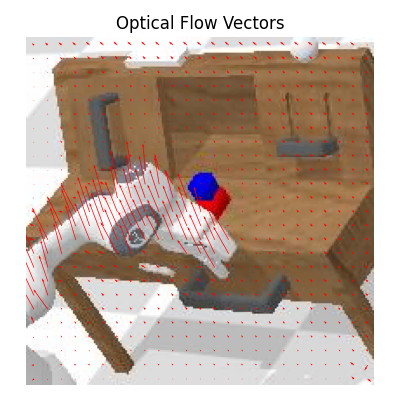

In [19]:
from dawn.models.system2.flow_utils import visualize_flow_vectors_as_PIL, FlowNormalizer
flow_normalizer = FlowNormalizer(256, 256)
this_flow = generated_flow.detach().cpu()
org_flow = flow_normalizer.unnormalize(this_flow[:, :2].permute(0, 2, 3, 1))
img_np = np.array(img_pil)
flow = org_flow[0]
visualize_flow_vectors_as_PIL(img_np, flow, step=8)

In [20]:
output = model.forward_eval(batch_data)

RuntimeError: torch.cat(): expected a non-empty list of Tensors

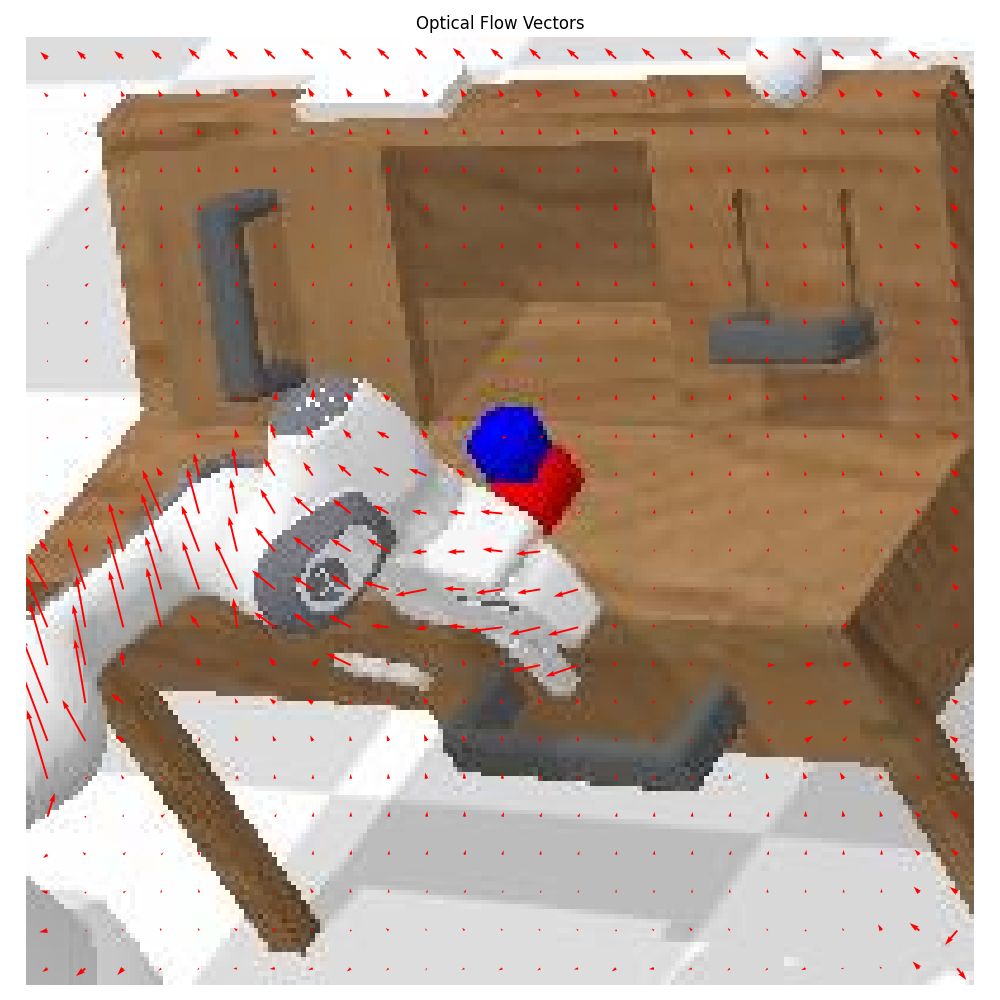

In [73]:
from dawn.models.system1.flow_utils import visualize_flow_vectors_as_PIL, FlowNormalizer
flow_normalizer = FlowNormalizer(256, 256)
this_flow = output["generated_flow"].detach().cpu()
org_flow = flow_normalizer.unnormalize(this_flow[:, :2].permute(0, 2, 3, 1))
img_np = np.array(img_pil)
flow = org_flow[0]
visualize_flow_vectors_as_PIL(img_np, flow, step=8)

In [29]:
vae = model.vae

In [13]:
vae.device

device(type='cpu')

In [13]:
vae = AutoencoderKL.from_pretrained(
        "madebyollin/sdxl-vae-fp16-fix")


In [14]:
model.vae = vae2

NameError: name 'vae2' is not defined

In [7]:
from PIL import Image
import numpy as np
import torch

img_pil = Image.open("/home/nero/Robotics/DAWN/data/calvin/dataset_opt/task_D_D/validation/episodes/659/rgb_static/0002.jpg").convert("RGB")
img = torch.tensor(np.array(img_pil)).unsqueeze(0).permute(0, 3, 1, 2) / 255.

In [8]:
img = img * 2 - 1 # Normalize to [-1, 1]

In [9]:
img.max()

tensor(1.)

In [10]:
from diffusers.image_processor import VaeImageProcessor
vae_image_processor = VaeImageProcessor()

In [15]:
latent = vae.encode(img).latent_dist.sample()

In [16]:
latent.shape

torch.Size([1, 4, 25, 25])

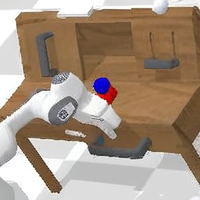

In [17]:
img_recon = vae.decode(latent).sample
img_recon = img_recon / 2 + 0.5  # Rescale to [0, 1]
img_recon = img_recon.clamp(0, 1)
img_recon = img_recon.squeeze(0).permute(1, 2, 0).detach().numpy() * 255
img_recon = img_recon.astype(np.uint8)
img_recon_pil = Image.fromarray(img_recon)
img_recon_pil

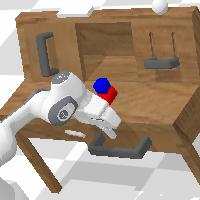

In [18]:
img_pil

In [40]:
from dawn.models.system1.raft import RAFT
flow = RAFT(flow_to_rgb=False)

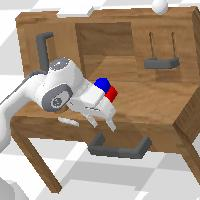

In [34]:
img2_pil = Image.open("/home/nero/Robotics/DAWN/data/calvin/dataset_opt/task_D_D/validation/episodes/659/rgb_static/0012.jpg").convert("RGB")
img2 = torch.tensor(np.array(img2_pil)).unsqueeze(0).permute(0, 3, 1, 2) / 255.
img2_pil

In [35]:
img.min()

tensor(-1.)

In [36]:
imgg = img
imgg2 = img2 * 2 - 1

In [41]:
this_flow = flow.gen_flow(torch.stack([imgg, imgg2], dim=1))

tensor(-1.) tensor(1.) torch.Size([1, 2, 3, 200, 200])
tensor(-1.) tensor(1.) torch.Size([1, 3, 200, 200])


In [42]:
this_flow.shape

torch.Size([1, 2, 200, 200])

In [43]:
add = this_flow.mean(dim=1, keepdim=True)
this_flow = torch.cat([this_flow, add], dim=1)

In [44]:
this_flow.min()

tensor(0.4575)

In [45]:
this_flow.max()

tensor(0.5024)

In [46]:
from dawn.models.system1.flow_utils import visualize_flow_vectors_as_PIL, FlowNormalizer
flow_normalizer = FlowNormalizer(200, 200)

In [47]:

org_flow = flow_normalizer.unnormalize(this_flow[:, :2].permute(0, 2, 3, 1))
org_flow.shape

(1, 200, 200, 2)

In [48]:
img_np = np.array(img_pil)
flow = org_flow[0]
print(img_np.shape, flow.shape)

(200, 200, 3) (200, 200, 2)


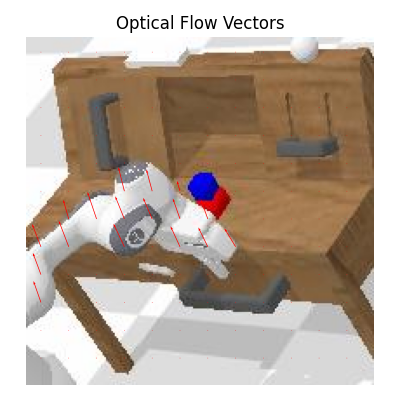

In [49]:
visualize_flow_vectors_as_PIL(img_np, flow)

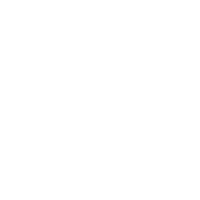

In [132]:
Image.fromarray((this_flow[0].permute(1, 2, 0).detach().numpy()).astype(np.uint8))

In [138]:
this_flow_norm = this_flow * 2 - 1 # Normalize to [-1, 1]

In [139]:
this_flow_norm.max()

tensor(0.1591)

In [140]:
latent_flow = vae.encode(this_flow_norm).latent_dist.sample()

In [141]:
flow_recon = vae.decode(latent_flow).sample

In [142]:
flow_recon = flow_recon / 2 + 0.5  # Rescale to [0, 1]
flow_recon = flow_recon.clamp(0, 1)

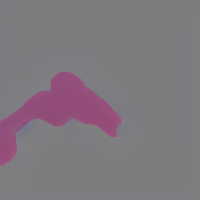

In [143]:
Image.fromarray((flow_recon[0].permute(1, 2, 0).detach().numpy() * 255).astype(np.uint8))

In [145]:
flow_recon.min(), flow_recon.max()

(tensor(0.2933, grad_fn=<MinBackward1>),
 tensor(0.6382, grad_fn=<MaxBackward1>))

In [147]:
((flow_recon - this_flow).abs()).mean()

tensor(0.0090, grad_fn=<MeanBackward0>)

In [148]:
diff = flow_recon - this_flow


In [112]:
flow_recon.shape

torch.Size([1, 3, 200, 200])

In [149]:

recon_flow = flow_normalizer.unnormalize(flow_recon[:, :2].permute(0, 2, 3, 1).detach())
recon_flow.shape

(1, 200, 200, 2)

In [159]:
img_np = np.array(img_pil)
flow = recon_flow[0]
print(img_np.shape, flow.shape)

(200, 200, 3) (200, 200, 2)


In [153]:
flow.shape

(200, 200, 2)

In [154]:
flow.max()

55.261093

In [166]:
mag = np.sqrt((flow ** 2).sum(axis=-1))
mag.shape

(200, 200)

In [169]:
flow[mag < 10] = 0

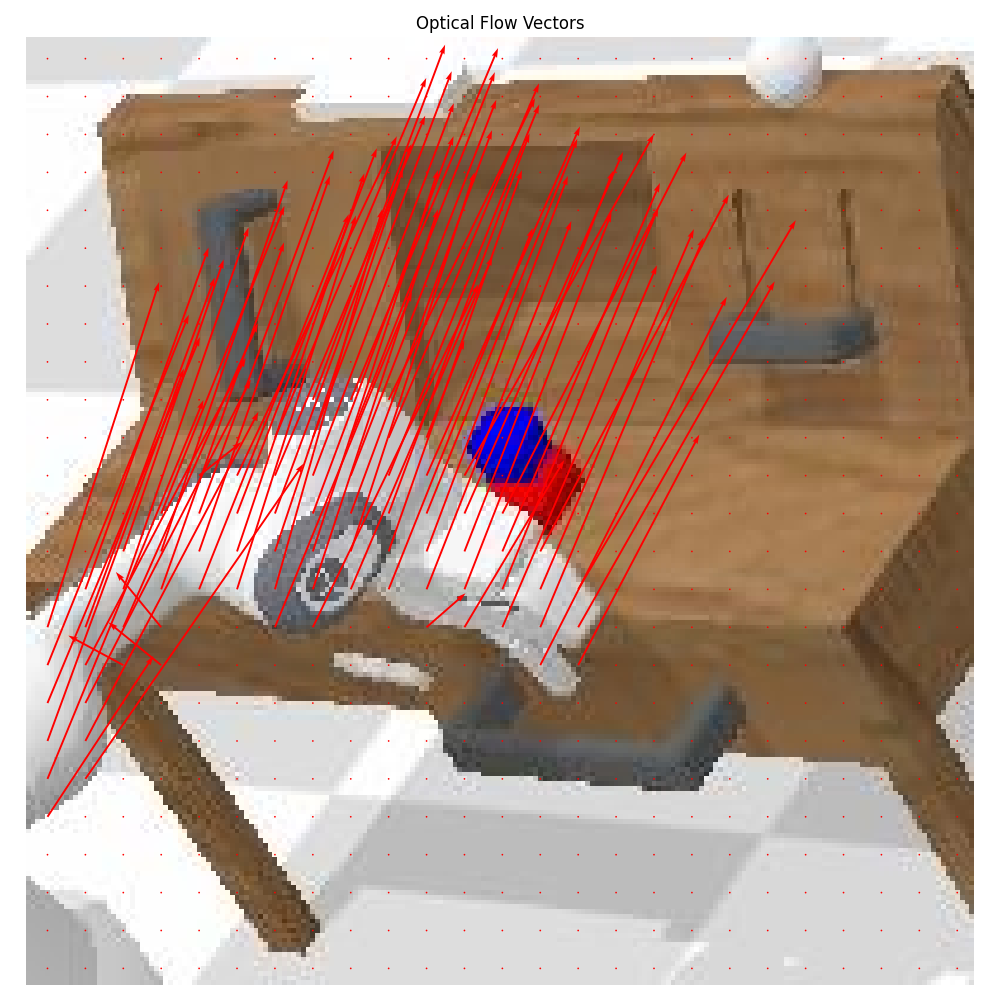

In [170]:
visualize_flow_vectors_as_PIL(img_np, flow, step = 8)

In [98]:
import cv2
image1 = this_flow[0].permute(1, 2, 0).detach().numpy() * 255
image1 = image1.astype(np.uint8)
image2 = flow_recon[0].permute(1, 2, 0).detach().numpy() * 255
image2 = image2.astype(np.uint8)

difference = cv2.subtract(image1, image2)

# color the mask red
Conv_hsv_Gray = cv2.cvtColor(difference, cv2.COLOR_BGR2GRAY)
ret, mask = cv2.threshold(Conv_hsv_Gray, 0, 255,cv2.THRESH_BINARY_INV |cv2.THRESH_OTSU)
difference[mask != 255] = [0, 0, 255]

# add the red mask to the images to make the differences obvious
image1[mask != 255] = [0, 0, 255]
image2[mask != 255] = [0, 0, 255]


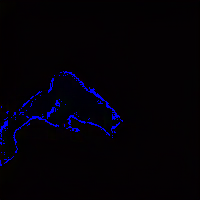

In [100]:
Image.fromarray(difference)

In [102]:
np.array(img_pil)

array([[[221, 221, 221],
        [221, 221, 221],
        [221, 221, 221],
        ...,
        [251, 255, 255],
        [249, 255, 255],
        [249, 255, 255]],

       [[221, 221, 221],
        [221, 221, 221],
        [221, 221, 221],
        ...,
        [242, 247, 251],
        [244, 249, 253],
        [246, 254, 255]],

       [[221, 221, 221],
        [221, 221, 221],
        [221, 221, 221],
        ...,
        [254, 255, 255],
        [252, 255, 255],
        [251, 255, 255]],

       ...,

       [[177, 177, 177],
        [176, 176, 176],
        [176, 176, 176],
        ...,
        [234, 234, 234],
        [234, 234, 234],
        [231, 231, 231]],

       [[177, 177, 177],
        [177, 177, 177],
        [176, 176, 176],
        ...,
        [254, 254, 254],
        [246, 246, 246],
        [234, 234, 234]],

       [[177, 177, 177],
        [177, 177, 177],
        [177, 177, 177],
        ...,
        [255, 255, 255],
        [241, 241, 241],
        [221, 221, 221]]

In [109]:
from transformers import AutoModel

In [112]:
from diffusers import DiffusionPipeline

pipe = DiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5")


Loading pipeline components...: 100%|██████████| 7/7 [00:04<00:00,  1.70it/s]


In [113]:
pipe

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.33.1",
  "_name_or_path": "stable-diffusion-v1-5/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [173]:
latent.shape

torch.Size([1, 4, 25, 25])

In [181]:
latent = torch.rand(4, 4, 32, 32)

In [176]:
from torch import nn

In [199]:
modules = nn.Sequential(
    nn.Conv2d(4, 64, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
    nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
    nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
    nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
)

In [200]:
x = modules(latent)
x.shape

torch.Size([4, 512, 2, 2])